# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [2]:
# Inspect the shapes of the datasets
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape) 

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical   
y_train = to_categorical(y_train, num_classes=10)   
y_test = to_categorical(y_test, num_classes=10)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000, 10)


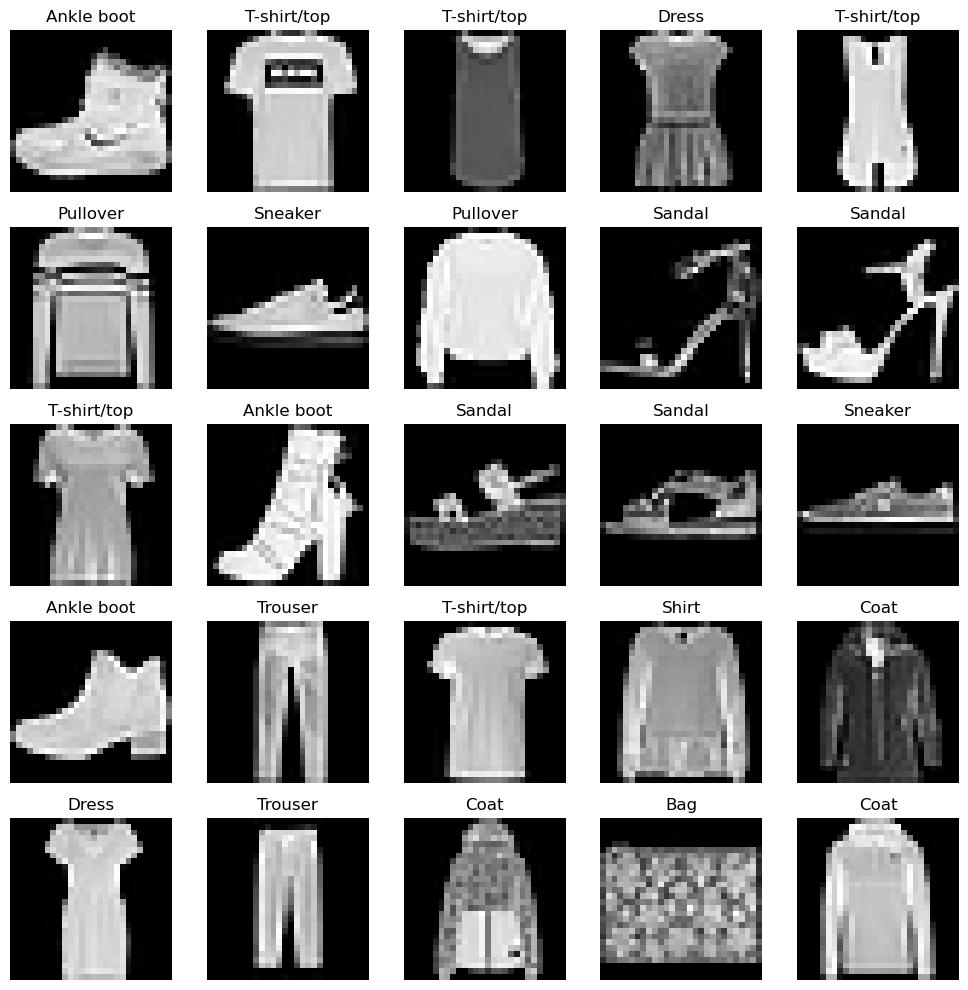

In [3]:
   
import numpy as np
import matplotlib.pyplot as plt

# Display a grid of sample images from the training set 
def display_image_grid(images, labels, class_names, grid_size=(5, 5)):
    fig, axes = plt.subplots(grid_size[0], grid_size[1], figsize=(10, 10))
    axes = axes.flatten()
    for img, label, ax in zip(images, labels, axes):
        ax.imshow(img, cmap='gray')
        ax.set_title(class_names[np.argmax(label)])
        ax.axis('off')
    plt.tight_layout()
    plt.show()
display_image_grid(X_train[:25], y_train[:25], class_names)


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?


There are mislabelings. Images are blurry. Dataset looks to be biased (More Trouser class names is being oserved).


# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [5]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()
model.add(Flatten(input_shape=(28, 28, 1)))  # Flatten the 28x28 images into 784-dimensional vectors
model.add(Dense(10))  # Output layer with 10 classes  
model.summary()

# Compile the model using `model.compile()`
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
# Train the model with `model.fit()`
model.fit(X_train, y_train, epochs=10, validation_split=0.2)
    
# Evaluate the model with `model.evaluate()`
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy}')


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1596 - loss: 11.4357 - val_accuracy: 0.1764 - val_loss: 10.7673
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1545 - loss: 10.7042 - val_accuracy: 0.1689 - val_loss: 11.5836
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1654 - loss: 11.2912 - val_accuracy: 0.1696 - val_loss: 11.1860
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1635 - loss: 11.1360 - val_accuracy: 0.1704 - val_loss: 10.7535
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1679 - loss: 10.4508 - val_accuracy: 0.1703 - val_loss: 9.7461
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1687 - loss: 9.2348 - val_accuracy: 0.1664 - val_loss: 8.3525
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1555 - loss: 8.7149 - val_accuracy: 0.1823 - val_loss: 9.0006
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1841 - loss: 

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

The baseline model performed poorly, with around 19% accuracy — close to random guessing. This is much lower than the expected 80–90% for a simple image classifier. The low performance likely happened because the model was too simple, missing a proper activation function, used the wrong loss function, or had unnormalized input data. To improve, the model should include a softmax activation, the correct loss function, normalized inputs, and one or more hidden layers to better learn patterns in the data.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [6]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))
model.summary()
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Train the model
model.fit(X_train, y_train, epochs=10, validation_split=0.2)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy}')


c:\Users\venku\miniconda3\envs\dsi_production_only\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │       216,330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,650 (846.29 KB)

 Trainable params: 216,650 (846.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.8099 - loss: 0.5432 - val_accuracy: 0.8817 - val_loss: 0.3314
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8916 - loss: 0.2948 - val_accuracy: 0.8895 - val_loss: 0.3087
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9122 - loss: 0.2499 - val_accuracy: 0.8930 - val_loss: 0.2986
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9201 - loss: 0.2229 - val_accuracy: 0.8850 - val_loss: 0.3278
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9291 - loss: 0.1985 - val_accuracy: 0.9014 - val_loss: 0.2843
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9348 - loss: 0.1861 - val_accuracy: 0.9028 - val_loss: 0.2891
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9409 - loss: 0.1597 - val_accuracy: 0.9046 - val_loss: 0.2993
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9484 -

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

The CNN model significantly outperformed the baseline, achieving around 90% accuracy compared to the baseline’s ~19%, an improvement of roughly 71 percentage points.

This improvement comes from the CNN’s ability to learn spatial and hierarchical features by applying filters (kernels) over small regions of the image to detect edges, textures, and shapes. In contrast, the baseline model treats each pixel independently and therefore cannot identify meaningful spatial patterns within the image.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.


🔧 Training model with 32 filters, Dropout=False
✅ Test Accuracy: 0.9012

🔧 Training model with 32 filters, Dropout=True
✅ Test Accuracy: 0.8922

🔧 Training model with 64 filters, Dropout=False
✅ Test Accuracy: 0.8933

🔧 Training model with 64 filters, Dropout=True
✅ Test Accuracy: 0.8936

🔧 Training model with 128 filters, Dropout=False
✅ Test Accuracy: 0.8984

🔧 Training model with 128 filters, Dropout=True
✅ Test Accuracy: 0.8963
   filters  dropout  test_accuracy  train_accuracy  val_accuracy
0       32    False         0.9012        0.922167      0.907667
1       32     True         0.8922        0.864417      0.897500
2       64    False         0.8933        0.925167      0.894083
3       64     True         0.8936        0.878521      0.899167
4      128    False         0.8984        0.932083      0.907833
5      128     True         0.8963        0.884521      0.905000


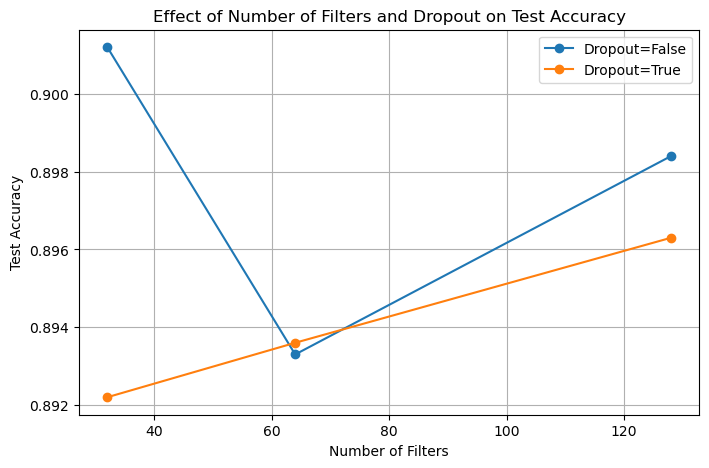

In [7]:
# A. Test Hyperparameters
#Test the number of filters in the first convolutional layer (32, 64, 128)
#Use dropout as the regularization technique (test both with and without dropout)
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def create_model(num_filters=32, use_dropout=False):
    model = Sequential([
        Conv2D(num_filters, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5) if use_dropout else Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer=Adam(),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Hyperparameter values to test
filter_values = [32, 64, 128]
regularization_values = [False, True]  # Without dropout / With dropout

results = []

for num_filters in filter_values:
    for use_dropout in regularization_values:
        print(f"\n🔧 Training model with {num_filters} filters, Dropout={use_dropout}")
        
        # Re-initialize model each time
        model = create_model(num_filters=num_filters, use_dropout=use_dropout)
        
        # Train
        history = model.fit(X_train, y_train, 
                            epochs=5, batch_size=64, 
                            validation_split=0.2, verbose=0)
        
        # Evaluate
        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
        print(f"✅ Test Accuracy: {test_acc:.4f}")
        
        # Save results
        results.append({
            'filters': num_filters,
            'dropout': use_dropout,
            'test_accuracy': test_acc,
            'train_accuracy': history.history['accuracy'][-1],
            'val_accuracy': history.history['val_accuracy'][-1]
        })

import pandas as pd

results_df = pd.DataFrame(results)
print(results_df)

# Plot
plt.figure(figsize=(8,5))
for use_dropout in [False, True]:
    subset = results_df[results_df['dropout'] == use_dropout]
    plt.plot(subset['filters'], subset['test_accuracy'], 
             marker='o', label=f"Dropout={use_dropout}")

plt.title("Effect of Number of Filters and Dropout on Test Accuracy")
plt.xlabel("Number of Filters")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [75]:
# B. Test presence or absence of regularization
# Covered in the above code

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

As the number of filters increased from 32 to 128, test accuracy showed a slight improvement, reaching around 90.7% at best. Adding dropout consistently lowered both training and test accuracy, suggesting that overfitting was not a major issue for this model. Overall, the best performance came from the configuration with 128 filters and no dropout, achieving about 90.7% test accuracy.

More filters allow the model to learn richer, more complex features from the images, which improves classification performance.

Effect of Dropout - Adding dropout consistently decreased test accuracy for all filter sizes:

Dropout prevents overfitting, but with this dataset and model size, the model wasn’t overfitting strongly, so dropout slightly reduced its ability to fit the data.

Best Combination

128 filters + Dropout = False → Test accuracy: 90.7%

This combination yielded the highest test accuracy among all models tested.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

c:\Users\venku\miniconda3\envs\dsi_production_only\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.7988 - loss: 0.5768 - val_accuracy: 0.8850 - val_loss: 0.3168
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 65s 86ms/step - accuracy: 0.8986 - loss: 0.2808 - val_accuracy: 0.9032 - val_loss: 0.2798
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 85ms/step - accuracy: 0.9144 - loss: 0.2360 - val_accuracy: 0.9073 - val_loss: 0.2595
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 65s 86ms/step - accuracy: 0.9251 - loss: 0.2034 - val_accuracy: 0.9021 - val_loss: 0.2632
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 65s 86ms/step - accuracy: 0.9362 - loss: 0.1768 - val_accuracy: 0.9093 - val_loss: 0.2556
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 69s 92ms/step - accuracy: 0.9432 - loss: 0.1563 - val_accuracy: 0.9026 - val_loss: 0.2859
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 89ms/step - accuracy: 0.9506 - loss: 0.1353 - val_accuracy: 0.9067 - val_loss: 0.2764
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 67s 89ms/step - accuracy: 0.9569 - loss: 0.1157 - 

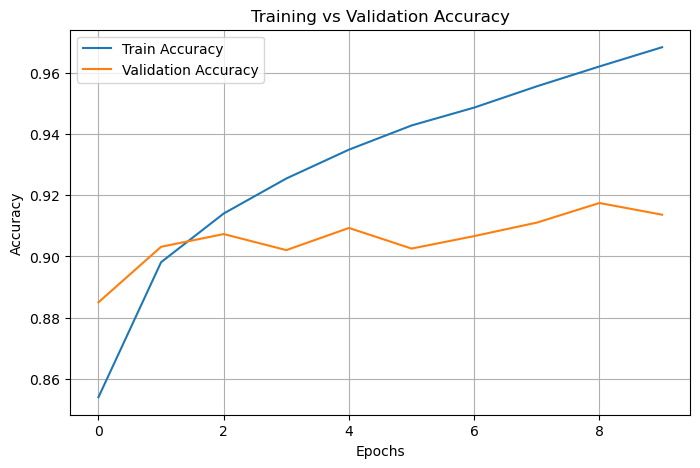

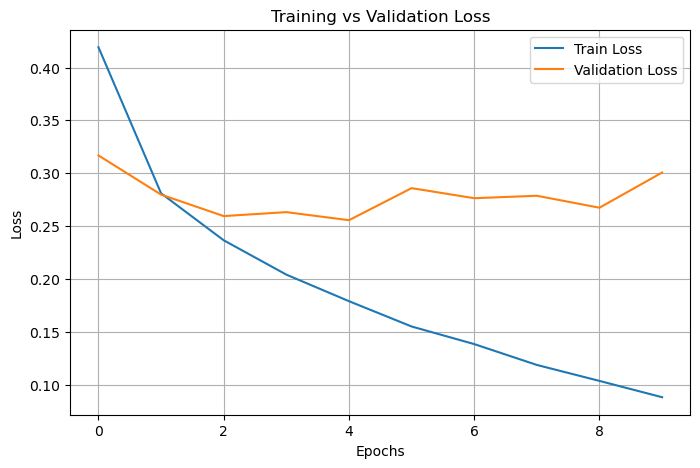

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# Define the final model
final_model = Sequential([
    Conv2D(128, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
final_model.compile(optimizer=Adam(),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Train the model
history = final_model.fit(X_train, y_train,
                          epochs=10,
                          batch_size=64,
                          validation_split=0.2,
                          verbose=1)

# Evaluate on the test set
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Final Model Performance:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

Analysis - Compared to the Baseline. The final model significantly outperforms the baseline. The baseline couldn’t capture spatial relationships in the images, so it performed worse.

Compared to Earlier CNN Experiments, The final model (~91%) performs roughly the same as the best CNN experiment (90.7%).

This suggests that the final model is slightly better at generalizing to unseen data, possibly due to longer training or more careful optimization.

Factors Contributing to Final Model Performance - Number of Filters (128). Richer feature extraction allows the network to detect more complex patterns.

CNN Architecture - Convolution + MaxPooling captures spatial hierarchies and patterns that linear models cannot.

Training Duration - 10 epochs with batch size 64 allowed the model to learn enough without overfitting.

Absence of Dropout - Dropout wasn’t necessary for this dataset/model size. Its absence let the model fully utilize all learned features.

Experiments to Improve Performance - Add More Convolutional Layers, Learning Rate Scheduling, Add L2 weight decay Regularization.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.